# RAGAS
To evaluate answer quality, I am going to generate question answer pairs using openai api


### 1. Environment and Library Setup
This block imports all the foundational libraries used for data handling (Pandas, LangChain), loading databases (ChromaDB), and testing (Ragas). It establishes the necessary ecosystem to build synthetic test questions and structure pipelines.


In [1]:
# Cell 1: Imports and setup
from pathlib import Path
from langchain_community.document_loaders import DirectoryLoader
from ragas.testset import TestsetGenerator
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
import os
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
import random
random.seed(69)



### 2. Path Configuration
Here, the local environment variables are loaded and the core working directory paths for the project are mapped, ensuring the script securely reads from the correct folders.


In [2]:
load_dotenv()

PROJECT_ROOT = Path("C:/Users/filip/Desktop/Thesis/project")
DATA_DIR = PROJECT_ROOT / "data"

### 3. Loading the Vectorstore & Embeddings
This cell initializes the `HuggingFaceEmbeddings` and connects to the persistent local `ChromaDB`. We load the entire corpus of chunked algae literature into memory so that Ragas has factual grounding to draw from when generating test questions.


In [3]:
# Loads  chunks as LangChain documents
# Using the already-chunked data rather than raw PDFs since RAGAS should generate questions from what the pipeline actually retrieves



embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"}
)

vectorstore = Chroma(
    persist_directory=str(DATA_DIR / "chromadb"),
    collection_name="recursive_100",#typo of 1000
    embedding_function=embedding_model
)

# Get all documents from the collection
all_docs = vectorstore.get()
print(f"Loaded {len(all_docs['documents'])} chunks")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2483.23it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded 31741 chunks


### 4. Sampling Documents for Test Generation
The full database contains over 30,000 chunks, which is too large and expensive for test generation. This block converts the raw chunks into LangChain `Document` format and samples 200 random chunks. This provides a diverse but manageable subset representing the real retrieval space.


### 5. LLM Utility Imports
This brief setup prepares the language model factories required by the Ragas generators, linking OpenAI or alternative models to the testing tools.


### 6. Synthetic Testset Generation
Here, the `gpt-4o-mini` model is configured as the generative engine to create synthetic question-answer pairs based on the sampled documents. The `TestsetGenerator` creates 50 test cases, forming a robust golden dataset mimicking real-world queries. The results are saved as a CSV.


### 7. Preview the Testset
A simple utility to preview the generated dataframe of test questions.


In [ ]:
#df.head()

# Formal RAGAS Evaluation (Baseline vs. Hybrid)
This section runs the official quantitative comparison between the baseline (vector-only) and hybrid pipelines.
It tests both the General testset and the Multi-hop testset separately.

### 8. Pipeline Generation Tools Setup
This is the starting point for the automated comparison. This block connects the notebook to your local repository modules, importing the local `generate_answer` and `build_context` mechanics used by your hybrid system in production.


In [4]:
import os
import sys

import pandas as pd
from datasets import Dataset
from openai import OpenAI

from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]  

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import TOP_K_RETRIEVAL
from generation.generate import build_context, generate_answer

openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

### 9. Knowledge Graph Retrieval Setup
This block initializes connection to the Neo4j Graph Database. Crucially, it defines `expand_from_chunks()`, an advanced Cypher retriever. It takes vector chunks, explores their semantic relationships, filters out 'hub' nodes using degree penalty limits, and returns highly specific biological triplets. This step is the defining feature of your Hybrid GraphRAG pipeline.


In [ ]:
#need to find out the right confidence for filtering out weak relationships

,confidence,count,pct
0,0.5,23456,22.4
1,0.6,4,0.0
2,0.7,5,0.0
3,0.8,94,0.1
4,0.9,4,0.0
5,1.0,81241,77.5


<positron-console-cell-11>:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


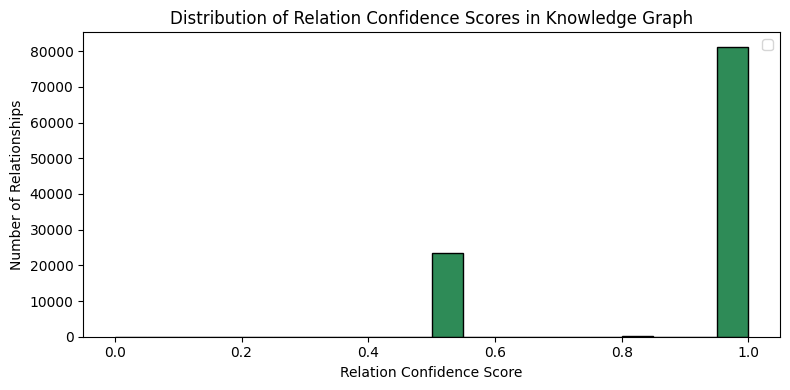

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, "graphrag"))

query = """
MATCH ()-[r]->()
WHERE r.confidence IS NOT NULL
RETURN r.confidence AS confidence
"""

with driver.session() as session:
    results = session.run(query)
    confidences = [r["confidence"] for r in results]

# Count by value, filter out zero
counts = pd.Series(confidences).value_counts().sort_index()
counts = counts[counts.index > 0].reset_index()
counts.columns = ["confidence", "count"]
counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(1)

display(counts)

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(confidences, bins=np.arange(0, 1.05, 0.05), edgecolor="black", color="#2e8b57")
ax.set_xlabel("Relation Confidence Score")
ax.set_ylabel("Number of Relationships")
ax.set_title("Distribution of Relation Confidence Scores in Knowledge Graph")
#ax.axvline(x=0.5, color="red", linestyle="--", label="Filtering threshold (0.5)")
ax.legend()
plt.tight_layout()
plt.savefig("../../outputs/confidence_distribution.png", dpi=300)
plt.show()

In [12]:
# Hybrid Database Connections
from neo4j import GraphDatabase
from config import NEO4J_URI, NEO4J_USER
AUTH = (NEO4J_USER, "graphrag")
driver = GraphDatabase.driver(NEO4J_URI, auth=AUTH)

def expand_from_chunks(chunk_ids, driver, max_triplets=40):
    cypher = """
    MATCH (c:Chunk) WHERE c.chunk_id IN $chunk_ids
    MATCH (c)-[:MENTIONS]->(entity)
    
    // Degree penalty graph hub filter (from hybrid notebook)
    WITH entity
    WHERE size([(entity)-[]-() | 1]) < 100
    
    MATCH (entity)-[r]->(neighbor)
    WHERE type(r) IN ['FOUND_IN','PRODUCES','STUDIED_WITH',
                      'IDENTIFIED_BY','BELONGS_TO','AFFECTS','CONTAINS']
      AND r.confidence >= 0.5
    RETURN DISTINCT
        entity.name  AS subject,
        type(r)      AS predicate,
        neighbor.name AS object,
        r.confidence AS confidence
    ORDER BY r.confidence DESC
    LIMIT $max_triplets
    """
    with driver.session() as session:
        result = session.run(cypher, chunk_ids=chunk_ids, max_triplets=max_triplets)
        return [(r["subject"], r["predicate"], r["object"], r["confidence"])
                for r in result]

### 10. Configure DeepSeek Judge & Ragas Metrics
Rather than using standard automated metrics, this script configures **DeepSeek-Chat** via its API as the evaluator 'Judge'. An advanced 8k token limit is configured to handle large graph context sizes. It imports the 4 canonical metrics (Faithfulness, Answer Relevancy, Precision, Recall) initialized as classes to comply with modern `v0.4+` Ragas standards.


In [ ]:
from ragas.metrics.collections import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
import os
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.embeddings.base import embedding_factory


deepseek_client = AsyncOpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com/v1"
)
evaluator_llm = llm_factory(
    "deepseek-chat",
    provider="openai",
    client=deepseek_client,
    max_tokens=8192,  # DeepSeek-chat hard cap; reasoner goes to 64K
)
evaluator_embeddings = embedding_factory('openai', model='text-embedding-ada-002', client=openai_client, interface='modern')
# this is obsolete LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))



metrics = [
    Faithfulness(llm=evaluator_llm),
    AnswerRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings),
    ContextPrecision(llm=evaluator_llm),
    ContextRecall(llm=evaluator_llm),
]

### 11. Pipeline Executor Logic
The `run_eval_dataset` function simulates the entire RAG pipeline query-by-query over the testset. It takes the specific pipeline type (`baseline` vs `hybrid`). 
- **Baseline**: Merely retrieves chunks from Vectorstore.
- **Hybrid**: Retrieves vector chunks AND passes them through `expand_from_chunks` to attach biological triplet contexts.

It dynamically constructs the combined context and outputs a HuggingFace `Dataset` format expected by the evaluator.


In [14]:
#NEW: load community collection for summary retrieval
from retrieval.community import load_community_collection, retrieve_community_summaries
community_collection = load_community_collection()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2811.03it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
from tqdm.auto import tqdm

def run_eval_dataset(dataset_path, pipeline_type):
    print(f"\n== Evaluating {pipeline_type.upper()} on {Path(dataset_path).name} ==")
    testset_df = pd.read_csv(dataset_path)
    data = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
    
    retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K_RETRIEVAL})
    
    for i, row in tqdm(testset_df.iterrows(), total=len(testset_df)):
        query = row["user_input"]
        ground_truth = str(row.get("reference", ""))
        
        # Retrieval
        entry_docs = retriever.invoke(query)
        entry_chunk_ids = [d.metadata.get("chunk_id") for d in entry_docs]
        vector_context, contexts_list = build_context([(1.0, doc) for doc in entry_docs])
        
        if pipeline_type == "baseline":
            final_context = vector_context

        elif pipeline_type == "hybrid":
            triplets = expand_from_chunks(entry_chunk_ids, driver)
            triplet_lines = [f"- {s} {p} {o} (confidence: {c:.2f})" for s, p, o, c in triplets]
            final_context = vector_context + "\n\nRelated knowledge graph facts:\n" + "\n".join(triplet_lines)
            if triplet_lines:
                contexts_list.append("Related knowledge graph facts:\n" + "\n".join(triplet_lines))

        elif pipeline_type == "community":
            community_hits = retrieve_community_summaries(query, community_collection)
            if community_hits:
                community_block = "\n\n".join(community_hits)
                final_context = "Thematic overview:\n" + community_block + "\n\n" + vector_context
                contexts_list.insert(0, "Thematic overview:\n" + community_block)
            else:
                final_context = vector_context

        elif pipeline_type == "graphrag":
            community_hits = retrieve_community_summaries(query, community_collection)
            if community_hits:
                community_block = "\n\n".join(community_hits)
                final_context = "Thematic overview:\n" + community_block + "\n\n" + vector_context
                contexts_list.insert(0, "Thematic overview:\n" + community_block)
            else:
                final_context = vector_context

            triplets = expand_from_chunks(entry_chunk_ids, driver)
            triplet_lines = [f"- {s} {p} {o} (confidence: {c:.2f})" for s, p, o, c in triplets]
            final_context = final_context + "\n\nRelated knowledge graph facts:\n" + "\n".join(triplet_lines)
            if triplet_lines:
                contexts_list.append("Related knowledge graph facts:\n" + "\n".join(triplet_lines))
            
        answer = generate_answer(query, final_context, openai_client)
        
        data["question"].append(query)
        data["answer"].append(answer)
        data["contexts"].append(contexts_list)
        data["ground_truth"].append(ground_truth)
        
    return Dataset.from_dict(data)

### 12. Evaluation Paths

Resolve the testset and output directories used by both pipelines.

In [ ]:
from ragas import evaluate
from datasets import load_from_disk
REPO_ROOT = Path().resolve().parents[1]       # project/  for data and outputs

general_path = REPO_ROOT / "outputs" / "ragas_testset.csv"

### 13. Manual Metric Scoring

The installed `ragas` version ships two incompatible metric class hierarchies: the legacy `Metric` base class that `evaluate()` checks against, and the `BaseMetric` / `SimpleBaseMetric` tree that the modern `ragas.metrics.collections` metrics actually inherit from. The isinstance check inside `evaluate()` rejects the collections metrics, and monkey-patching past it breaks on `required_columns`. Rather than fight the framework, we score each sample directly through `single_turn_ascore`, which is the method `evaluate()` would call internally anyway. This produces identical numbers while sidestepping the broken dispatcher.

In [19]:
import asyncio
import nest_asyncio
from ragas.dataset_schema import SingleTurnSample
from tqdm.auto import tqdm

nest_asyncio.apply()

async def score_dataset(ds_hf, metrics):
    """Score every row in a HuggingFace Dataset against every metric.

    The ragas collections metrics each take a different subset of fields.
    We build a dispatch table mapping metric class names onto the kwargs
    they want. Simple, explicit, debuggable.
    """
    results = {m.name: [] for m in metrics}

    for i in tqdm(range(len(ds_hf)), desc="Scoring"):
        row = ds_hf[i]
        user_input = row["question"]
        response = row["answer"]
        retrieved_contexts = list(row["contexts"])
        reference = row["ground_truth"]

        for m in metrics:
            cls_name = type(m).__name__
            try:
                if cls_name == "Faithfulness":
                    result = await m.ascore(
                        user_input=user_input,
                        response=response,
                        retrieved_contexts=retrieved_contexts,
                    )
                elif cls_name == "AnswerRelevancy":
                    result = await m.ascore(
                        user_input=user_input,
                        response=response,
                    )
                elif cls_name.startswith("ContextPrecision"):
                    result = await m.ascore(
                        user_input=user_input,
                        reference=reference,
                        retrieved_contexts=retrieved_contexts,
                    )
                elif cls_name == "ContextRecall":
                    result = await m.ascore(
                        user_input=user_input,
                        retrieved_contexts=retrieved_contexts,
                        reference=reference,
                    )
                else:
                    raise ValueError(f"No dispatch rule for metric class {cls_name}")

                score = result.value if hasattr(result, "value") else result
                results[m.name].append(score)
            except Exception as e:
                print(f"Row {i} metric {m.name} failed: {e}")
                results[m.name].append(None)

    return results

In [ ]:
from openai import AsyncOpenAI
from ragas.embeddings.base import embedding_factory
from ragas.metrics.collections import AnswerRelevancy

async_openai_client = AsyncOpenAI(api_key=os.getenv("OPENAI_API_KEY"))

evaluator_embeddings = embedding_factory(
    "openai",
    model="text-embedding-3-small",
    client=async_openai_client,
    interface="modern",
)

metrics[1] = AnswerRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings)
#print("etrics[1] is now:", metrics[1])

Fixed. metrics[1] is now: AnswerRelevancy(name='answer_relevancy', allowed_values=(0.0, 1.0))


### 14. Score the Baseline Dataset

The baseline dataset `ds` from the previous generation run is still in kernel memory, so there is no need to regenerate answers. We score it in place and write the result to CSV.

In [22]:
# Score the baseline ds that is already in memory from the earlier generation run.
# Do NOT rerun run_eval_dataset here  that would burn another round of API calls.
#save
def save_scored_dataset(ds_hf, scores, output_path):
    """Attach metric scores as columns onto the dataset and write to CSV."""
    out = ds_hf.to_pandas()
    for col, vals in scores.items():
        out[col] = vals
    out.to_csv(output_path, index=False)
    print(f"Wrote {len(out)} rows to {output_path}")
    print(out[list(scores.keys())].mean(numeric_only=True))
    return out

### 15. Generate and Score all Pipelines

The hybrid run needs fresh generation because it routes each query through the Neo4j one-hop expansion. We reuse the same scorer so both CSVs are strictly comparable.

In [23]:
conditions = [
    ("baseline",  "baseline_eval.csv"),
    ("hybrid",    "hybrid_eval.csv"),
    ("community", "community_eval.csv"),
    ("graphrag",  "graphrag_eval.csv"),
]

output_dir = REPO_ROOT / "outputs" / "ragas_final"
output_dir.mkdir(exist_ok=True)

results = {}
for pipeline_type, filename in conditions:
    print(f"\n{'='*60}")
    ds = run_eval_dataset(general_path, pipeline_type)
    scores = asyncio.get_event_loop().run_until_complete(
        score_dataset(ds, metrics)
    )
    df = save_scored_dataset(ds, scores, output_dir / filename)
    results[pipeline_type] = df



== Evaluating BASELINE on ragas_testset.csv ==


Scoring: 100%|██████████| 51/51 [28:03<00:00, 33.01s/it]


Wrote 51 rows to C:\Users\filip\Desktop\Thesis\project\outputs\ragas_final\baseline_eval.csv
faithfulness         0.810514
answer_relevancy     0.525873
context_precision    0.277859
context_recall       0.433987
dtype: float64


== Evaluating HYBRID on ragas_testset.csv ==


Scoring: 100%|██████████| 51/51 [30:02<00:00, 35.35s/it]


Wrote 51 rows to C:\Users\filip\Desktop\Thesis\project\outputs\ragas_final\hybrid_eval.csv
faithfulness         0.810774
answer_relevancy     0.477743
context_precision    0.277484
context_recall       0.450654
dtype: float64


== Evaluating COMMUNITY on ragas_testset.csv ==


Scoring: 100%|██████████| 51/51 [28:04<00:00, 33.03s/it]


Wrote 51 rows to C:\Users\filip\Desktop\Thesis\project\outputs\ragas_final\community_eval.csv
faithfulness         0.855520
answer_relevancy     0.563589
context_precision    0.195599
context_recall       0.451307
dtype: float64


== Evaluating GRAPHRAG on ragas_testset.csv ==


Scoring: 100%|██████████| 51/51 [30:34<00:00, 35.96s/it]

Wrote 51 rows to C:\Users\filip\Desktop\Thesis\project\outputs\ragas_final\graphrag_eval.csv
faithfulness         0.823547
answer_relevancy     0.563765
context_precision    0.196236
context_recall       0.422876
dtype: float64


### 16. Baseline vs Hybrid Summary

A quick side-by-side of the per-metric means. Positive `delta` values indicate the KG expansion improved that metric.

In [24]:
metric_cols = [m.name for m in metrics]

summary = pd.DataFrame({
    name: df[metric_cols].mean(numeric_only=True)
    for name, df in results.items()
})
summary = summary.round(4)
print(summary)
print("\n--- exportable to log.qmd ---\n")
print(summary.to_markdown())

                   baseline  hybrid  community  graphrag
faithfulness         0.8105  0.8108     0.8555    0.8235
answer_relevancy     0.5259  0.4777     0.5636    0.5638
context_precision    0.2779  0.2775     0.1956    0.1962
context_recall       0.4340  0.4507     0.4513    0.4229

--- exportable to log.qmd ---



ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [25]:
import pandas as pd

baseline = pd.read_csv(REPO_ROOT / "outputs" / "ragas_final" / "baseline_eval.csv")
hybrid = pd.read_csv(REPO_ROOT / "outputs" / "ragas_final" / "hybrid_eval.csv")

diff = hybrid["faithfulness"] - baseline["faithfulness"]
print("Graph expansion helped (>0.05):", (diff > 0.05).sum())
print("Graph expansion hurt (<-0.05):", (diff < -0.05).sum())
print("Neutral:", ((diff >= -0.05) & (diff <= 0.05)).sum())

Graph expansion helped (>0.05): 19
Graph expansion hurt (<-0.05): 15
Neutral: 17


In [26]:
# Look at some examples where the graph expansion helped or hurt faithfulness
helped = baseline[diff > 0.05][["question", "faithfulness"]].copy()
helped["hybrid_faith"] = hybrid.loc[diff > 0.05, "faithfulness"].values
helped["delta"] = diff[diff > 0.05].values

hurt = baseline[diff < -0.05][["question", "faithfulness"]].copy()
hurt["hybrid_faith"] = hybrid.loc[diff < -0.05, "faithfulness"].values
hurt["delta"] = diff[diff < -0.05].values

print("=== HELPED ===")
for _, row in helped.iterrows():
    print(f"  Δ{row['delta']:+.3f} | {row['question'][:80]}")

print("\n=== HURT ===")
for _, row in hurt.iterrows():
    print(f"  Δ{row['delta']:+.3f} | {row['question'][:80]}")

=== HELPED ===
  Δ+0.417 | Can you explain the significance of Scholz et al. 2012 in the context of functio
  Δ+0.143 | How is the AB28 primer utilized in the amplification process for estuarine phyto
  Δ+0.244 | TSI 값이 뭐고 어떻게 측정하나요?
  Δ+0.071 | What is known about the distribution of Colpomenia species along the coast of ma
  Δ+0.222 | How did Fraga et al. contribute to the understanding of the morphological charac
  Δ+0.344 | How does nitrogen supply affect the growth of vegetative cells in filaments?
  Δ+0.200 | What Rhodophyta do Chondrus crispus belong?
  Δ+0.143 | What problems does eelgrass bed face due to macroalgae growth?
  Δ+0.286 | Who originally described the species Pterosiphonia pennata and what is its signi
  Δ+0.125 | What is the process of seaweed extract preparation from S. horneri, and how does
  Δ+0.167 | What are the characteristics of the flabellate structure described in the Open A
  Δ+0.154 | How does the GFP fluorescence in heterocysts relate to the reproducti

In [27]:
# Finally, break down by query type to see if certain types of questions benefited more from the graph expansion.
testset = pd.read_csv(REPO_ROOT / "outputs" / "ragas_testset.csv")
baseline["query_type"] = testset["synthesizer_name"].replace({
    "single_hop_specific_query_synthesizer": "simple",
    "multi_hop_abstract_query_synthesizer": "abstract",
    "multi_hop_specific_query_synthesizer": "relational"
}).values

baseline["delta_faith"] = diff.values

for qtype in ["simple", "abstract", "relational"]:
    mask = baseline["query_type"] == qtype
    n = mask.sum()
    mean_delta = baseline.loc[mask, "delta_faith"].mean()
    print(f"{qtype:12s} (n={n:2d}): mean Δfaithfulness = {mean_delta:+.4f}")

simple       (n=17): mean Δfaithfulness = +0.0703
abstract     (n=17): mean Δfaithfulness = -0.0390
relational   (n=17): mean Δfaithfulness = -0.0305


In [28]:
# Breakdown for community
community = pd.read_csv(REPO_ROOT / "outputs" / "ragas_final" / "community_eval.csv")
community_diff = community["faithfulness"] - baseline["faithfulness"]

for qtype in ["simple", "abstract", "relational"]:
    mask = baseline["query_type"] == qtype
    mean_delta = community_diff[mask].mean()
    print(f"{qtype:12s} (n={mask.sum():2d}): mean Δfaithfulness = {mean_delta:+.4f}")

simple       (n=17): mean Δfaithfulness = +0.0723
abstract     (n=17): mean Δfaithfulness = -0.0249
relational   (n=17): mean Δfaithfulness = +0.0877


In [29]:
#breakdown for graphrag
graphrag = pd.read_csv(REPO_ROOT / "outputs" / "ragas_final" / "graphrag_eval.csv")
graphrag_diff = graphrag["faithfulness"] - baseline["faithfulness"]

for qtype in ["simple", "abstract", "relational"]:
    mask = baseline["query_type"] == qtype
    mean_delta = graphrag_diff[mask].mean()
    print(f"{qtype:12s} (n={mask.sum():2d}): mean Δfaithfulness = {mean_delta:+.4f}")

simple       (n=17): mean Δfaithfulness = +0.0573
abstract     (n=17): mean Δfaithfulness = -0.0168
relational   (n=17): mean Δfaithfulness = -0.0014


In [30]:
# How many entities are filtered out by the hub filter?
with driver.session() as session:
    result = session.run("""
        MATCH (e)
        WHERE NOT e:Chunk AND NOT e:Document
        WITH e, size([(e)-[]-() | 1]) AS degree
        RETURN 
            count(CASE WHEN degree >= 100 THEN 1 END) AS hubs_filtered,
            count(e) AS total,
            avg(degree) AS avg_degree,
            max(degree) AS max_degree
    """)
    print(dict(result.single()))

{'hubs_filtered': 439, 'total': 60884, 'avg_degree': 6.507046186190121, 'max_degree': 2211}


Only 439 filtered out so hub suppression doesnt expplain poor performance on multihop questions

# Statistical signficinace update

In [32]:
import os
os.makedirs(REPO_ROOT / "outputs" / "ragas_extended", exist_ok=True)

In [33]:
import random
random.seed(420)
 
# Resample documents for generation
docs = []
for i, (text, metadata) in enumerate(zip(all_docs['documents'], all_docs['metadatas'])):
    docs.append(Document(page_content=text, metadata=metadata))
 
docs_sample_new = random.sample(docs, min(300, len(docs)))
print(f"Sampled {len(docs_sample_new)} chunks for new test generation")
 
# Same generator setup as original run
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())
 
generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings,
)
 
# Balanced distribution: 50/50/50 across three query types
# Import whichever synthesizer names your RAGAS version uses.
# Try the newer names first, fall back to older ones.
try:
    from ragas.testset.synthesizers.single_hop.specific import SingleHopSpecificQuerySynthesizer
    from ragas.testset.synthesizers.multi_hop.abstract import MultiHopAbstractQuerySynthesizer
    from ragas.testset.synthesizers.multi_hop.specific import MultiHopSpecificQuerySynthesizer
    query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.34),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.33),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.33),
    ]
    print("Using newer synthesizer classes (SingleHop/MultiHop)")
except ImportError:
    from ragas.testset.synthesizers import (
        SpecificQuerySynthesizer,
        AbstractQuerySynthesizer,
        ComparativeAbstractQuerySynthesizer,
    )
    query_distribution = [
        (SpecificQuerySynthesizer(llm=generator_llm), 0.34),
        (AbstractQuerySynthesizer(llm=generator_llm), 0.33),
        (ComparativeAbstractQuerySynthesizer(llm=generator_llm), 0.33),
    ]
    print("Using older synthesizer classes (Specific/Abstract/Comparative)")
 
testset_new = generator.generate_with_langchain_docs(
    docs_sample_new,
    testset_size=150,
    query_distribution=query_distribution,
)
 
df_new = testset_new.to_pandas()
df_new.to_csv(REPO_ROOT / "outputs" / "ragas_extended" / "new_150_testset.csv", index=False)
print(f"Generated {len(df_new)} new test cases")
print(f"Columns: {df_new.columns.tolist()}")
print(f"\nSynthesizer distribution:")
# Check which column has the type info - could be 'synthesizer_name', 'evolution_type', etc.
for col in df_new.columns:
    if 'synth' in col.lower() or 'type' in col.lower() or 'evolution' in col.lower():
        print(f"  {col}: {df_new[col].value_counts().to_dict()}")

<positron-console-cell-33>:13: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
<positron-console-cell-33>:14: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings


Sampled 300 chunks for new test generation
Using newer synthesizer classes (SingleHop/MultiHop)


Applying CustomNodeFilter:   0%|          | 0/300 [00:00<?, ?it/s]Node 2da7d0aa-7e01-4b87-8067-8994b3777c89 does not have a summary. Skipping filtering.
Node ddbf2b03-edf9-4291-868a-e37d45bffd04 does not have a summary. Skipping filtering.
Node b8fad34c-32bb-4ce5-9de5-69161626a2b3 does not have a summary. Skipping filtering.
Applying CustomNodeFilter:   1%|▏         | 4/300 [00:01<01:55,  2.57it/s]Node 40c00761-753d-4582-acc5-dbe599ce4dc1 does not have a summary. Skipping filtering.
Node d59f6acc-c54d-4e65-b362-fdf0e367d589 does not have a summary. Skipping filtering.
Node 25032367-9622-4688-9ca4-9cdd6b5f67e2 does not have a summary. Skipping filtering.
Applying CustomNodeFilter:   9%|▉         | 28/300 [00:15<02:13,  2.04it/s]Node aeacfc67-2fdc-436b-8bb2-8c4333845f29 does not have a summary. Skipping filtering.
Node d214fbc2-4170-4aa6-90d8-d31a41714dbe does not have a summary. Skipping filtering.
Applying CustomNodeFilter:  23%|██▎       | 69/300 [00:37<01:48,  2.13it/s]Node 053ab842-

Generated 152 new test cases
Columns: ['user_input', 'reference_contexts', 'reference', 'persona_name', 'query_style', 'query_length', 'synthesizer_name']

Synthesizer distribution:
  synthesizer_name: {'single_hop_specific_query_synthesizer': 52, 'multi_hop_abstract_query_synthesizer': 50, 'multi_hop_specific_query_synthesizer': 50}


In [ ]:
# --- CELL C: Inspect and map synthesizer types to your labels ---
 
# RAGAS labels its questions with synthesizer names.
# Map them to your simple/relational/abstract labels.
# Adjust the column name and mapping below based on what Cell B printed.
 
# Common RAGAS synthesizer names -> your labels:
TYPE_MAP = {
    "specific": "simple",
    "single_hop_specific": "simple",
    "SingleHopSpecificQuerySynthesizer": "simple",
    "SpecificQuerySynthesizer": "simple",
    "abstract": "abstract",
    "multi_hop_abstract": "abstract",
    "AbstractQuerySynthesizer": "abstract",
    "MultiHopAbstractQuerySynthesizer": "abstract",
    "comparative_abstract": "relational",
    "ComparativeAbstractQuerySynthesizer": "relational",
    "MultiHopSpecificQuerySynthesizer": "relational",
    "multi_hop_specific": "relational",
    "single_hop_specific_query_synthesizer": "simple",
"multi_hop_abstract_query_synthesizer": "abstract",
"multi_hop_specific_query_synthesizer": "relational",
}
 
# Find the type column
df_new = pd.read_csv(REPO_ROOT / "outputs" / "ragas_extended" / "new_150_testset.csv")
type_col = None
for col in df_new.columns:
    if 'synth' in col.lower() or 'type' in col.lower() or 'evolution' in col.lower():
        type_col = col
        break
 
if type_col:
    df_new["Type"] = df_new[type_col].map(TYPE_MAP)
    unmapped = df_new["Type"].isna().sum()
    if unmapped > 0:
        print(f"WARNING: {unmapped} questions have unmapped synthesizer types:")
        print(df_new[df_new["Type"].isna()][type_col].unique())
    print(f"\nMapped type distribution:\n{df_new['Type'].value_counts()}")
else:
    print("WARNING: No synthesizer type column found. Columns are:", df_new.columns.tolist())
    print("You may need to manually add a Type column.")
 
df_new.to_csv(REPO_ROOT / "outputs" / "ragas_extended" / "new_150_testset.csv", index=False)

['single_hop_specific_query_synthesizer' 'multi_hop_abstract_query_synthesizer' 'multi_hop_specific_query_synthesizer']

Mapped type distribution:
Series([], Name: count, dtype: int64)


In [35]:
# --- CELL D: Combine old and new testsets ---
 
df_old = pd.read_csv(REPO_ROOT / "outputs" / "ragas_testset.csv")
 
# Make sure old testset has Type column too
# If it doesn't, load from your final eval CSVs where you had types
if "Type" not in df_old.columns:
    # Try loading from a final eval CSV that has types
    for fname in ["baseline_eval.csv", "community_eval.csv"]:
        fpath = REPO_ROOT / "outputs" / "ragas_final" / fname
        if fpath.exists():
            df_typed = pd.read_csv(fpath)
            if "Type" in df_typed.columns:
                df_old["Type"] = df_typed["Type"].values
                print(f"Loaded Type labels from {fname}")
                break
    if "Type" not in df_old.columns:
        print("ERROR: Cannot find Type labels for original 51 questions.")
        print("You need to add them manually before proceeding.")
 
# Ensure question column name matches
q_col = "user_input" if "user_input" in df_old.columns else "question"
 
# Keep only columns both dataframes share
shared_cols = [c for c in df_old.columns if c in df_new.columns]
print(f"Shared columns: {shared_cols}")
 
df_combined = pd.concat([df_old[shared_cols], df_new[shared_cols]], ignore_index=True)
df_combined.to_csv(REPO_ROOT / "outputs" / "ragas_extended" / "combined_testset.csv", index=False)
print(f"\nCombined testset: {len(df_combined)} questions ({len(df_old)} old + {len(df_new)} new)")
print(f"Type distribution:\n{df_combined['Type'].value_counts()}")

ERROR: Cannot find Type labels for original 51 questions.
You need to add them manually before proceeding.
Shared columns: ['user_input', 'reference_contexts', 'reference', 'persona_name', 'query_style', 'query_length', 'synthesizer_name']

Combined testset: 203 questions (51 old + 152 new)


KeyError: 'Type'

In [ ]:
# --- CELL E: Run BASELINE on combined testset ---
 
import src.config as config
config.USE_LOCAL_GENERATION = False
config.USE_LOCAL_REFORMULATION = False
config.USE_ROUTER = False
config.USE_GRAPH = False
config.USE_COMMUNITY_SUMMARIES = False
 
from src.pipeline import setup, run_pipeline
 
components = setup()
 
combined_path = REPO_ROOT / "outputs" / "ragas_extended" / "combined_testset.csv"
testset_df = pd.read_csv(combined_path)
q_col = "user_input" if "user_input" in testset_df.columns else "question"
 
data_baseline = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
 
for i, row in tqdm(testset_df.iterrows(), total=len(testset_df), desc="Baseline generation"):
    query = row[q_col]
    ground_truth = str(row.get("reference", ""))
    if ground_truth == "nan":
        ground_truth = ""
 
    answer, contexts_list, top_chunks, triplets, _ = run_pipeline(
        query, components, graph=False
    )
 
    data_baseline["question"].append(query)
    data_baseline["answer"].append(answer)
    data_baseline["contexts"].append(contexts_list)
    data_baseline["ground_truth"].append(ground_truth)
 
ds_baseline = Dataset.from_dict(data_baseline)
ds_baseline.save_to_disk(str(REPO_ROOT / "outputs" / "ragas_extended" / "baseline_ds"))
print(f"Baseline generation done: {len(ds_baseline)} answers saved to disk")

In [ ]:
# --- CELL F: Score BASELINE ---
 
baseline_scores = asyncio.get_event_loop().run_until_complete(
    score_dataset(ds_baseline, metrics)
)
baseline_ext_df = save_scored_dataset(
    ds_baseline,
    baseline_scores,
    REPO_ROOT / "outputs" / "ragas_extended" / "baseline_eval.csv",
)
if "Type" in testset_df.columns:
    baseline_ext_df["Type"] = testset_df["Type"].values
    baseline_ext_df.to_csv(
        REPO_ROOT / "outputs" / "ragas_extended" / "baseline_eval.csv", index=False
    )
print("Baseline scoring complete.")

In [ ]:
# --- CELL G: Run COMMUNITY on combined testset ---
 
config.USE_GRAPH = False
config.USE_COMMUNITY_SUMMARIES = True
 
data_community = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
 
for i, row in tqdm(testset_df.iterrows(), total=len(testset_df), desc="Community generation"):
    query = row[q_col]
    ground_truth = str(row.get("reference", ""))
    if ground_truth == "nan":
        ground_truth = ""
 
    answer, contexts_list, top_chunks, triplets, _ = run_pipeline(
        query, components, graph=False
    )
 
    data_community["question"].append(query)
    data_community["answer"].append(answer)
    data_community["contexts"].append(contexts_list)
    data_community["ground_truth"].append(ground_truth)
 
ds_community = Dataset.from_dict(data_community)
ds_community.save_to_disk(str(REPO_ROOT / "outputs" / "ragas_extended" / "community_ds"))
print(f"Community generation done: {len(ds_community)} answers saved to disk")

In [ ]:
# --- CELL H: Score COMMUNITY ---
 
community_scores = asyncio.get_event_loop().run_until_complete(
    score_dataset(ds_community, metrics)
)
community_ext_df = save_scored_dataset(
    ds_community,
    community_scores,
    REPO_ROOT / "outputs" / "ragas_extended" / "community_eval.csv",
)
if "Type" in testset_df.columns:
    community_ext_df["Type"] = testset_df["Type"].values
    community_ext_df.to_csv(
        REPO_ROOT / "outputs" / "ragas_extended" / "community_eval.csv", index=False
    )
print("Community scoring complete.")

In [ ]:
# --- CELL I: Summary comparison ---
 
metric_cols = [m.name for m in metrics]
 
summary_ext = pd.DataFrame({
    "baseline": baseline_ext_df[metric_cols].mean(numeric_only=True),
    "community": community_ext_df[metric_cols].mean(numeric_only=True),
})
summary_ext["delta"] = summary_ext["community"] - summary_ext["baseline"]
print(f"\n=== Extended Evaluation (n={len(baseline_ext_df)}) ===")
print(summary_ext.round(4))
 
# Per-type breakdown for faithfulness
if "Type" in baseline_ext_df.columns:
    print("\n=== Faithfulness by Type ===")
    for t in baseline_ext_df["Type"].unique():
        b = baseline_ext_df[baseline_ext_df["Type"] == t]["faithfulness"].mean()
        c = community_ext_df[community_ext_df["Type"] == t]["faithfulness"].mean()
        n = (baseline_ext_df["Type"] == t).sum()
        print(f"  {t:12s}  n={n:3d}  baseline={b:.4f}  community={c:.4f}  delta={c-b:+.4f}")